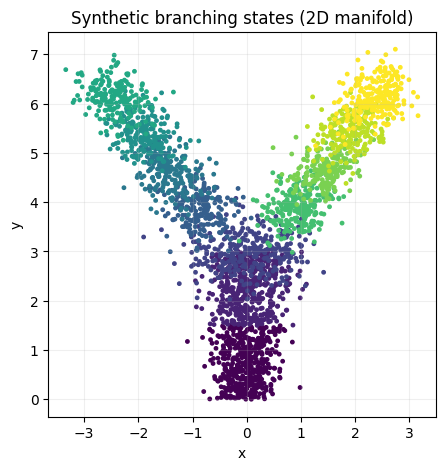

edges: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (2, 7), (7, 8), (8, 9), (9, 10)]
X shape: (3000, 124)


In [ ]:

# A) Create Synthetic Branching Data
# ----------------------------------

import numpy as np
import matplotlib.pyplot as plt


def _distribute_total(total, k):
    if k <= 0:
        return []
    base = total // k
    rem = total % k
    out = [base] * k
    for i in range(rem):
        out[i] += 1
    return out

def _expand_counts(N_per_state, K, n_trunk, n_left, n_right):
    if isinstance(N_per_state, (int, np.integer)):
        return [int(N_per_state)] * K
    N_per_state = list(N_per_state)
    if len(N_per_state) == K:
        return [int(x) for x in N_per_state]
    if len(N_per_state) == 3:
        trunk_total, left_total, right_total = map(int, N_per_state)
        counts = []
        counts += _distribute_total(trunk_total, n_trunk)
        counts += _distribute_total(left_total, n_left)
        counts += _distribute_total(right_total, n_right)
        if len(counts) != K:
            raise ValueError("Count expansion failed; check state numbers.")
        return counts
    raise ValueError(f"N_per_state must be int, length-K list, or length-3 tuple. Got length {len(N_per_state)}.")

def make_branching_Y_data_flexible(
    n_trunk_states=2,
    n_left_states=2,
    n_right_states=2,
    N_per_state=500,
    D=124,
    noise=0.35,
    trunk_len=3.0,
    junction_spread=0.6,
    branch_sep=2.2,
    branch_len=3.0,
    branch_y_offset=0.5,
    stem_x_base=0.25,
    stem_x_slope=0.05,
    branch_x_base=0.3,
    branch_x_slope=0.9,
    branch_x_noise=0.30,
    branch_y_noise=0.25,
    nonlinear=True,
    seed=0,
    states_start_at_1=False,

    # ---- NEW: branch marker injection ----
    add_markers=True,
    n_markers_each=12,
    marker_strength=3.0,
    marker_spread=0.5,
    marker_ramp=True,
    marker_seed=123,
):
    rng = np.random.default_rng(seed)

    n_trunk = int(n_trunk_states)
    n_left  = int(n_left_states)
    n_right = int(n_right_states)

    if n_trunk < 1:
        raise ValueError("n_trunk_states must be >= 1 (the last trunk state is the junction).")
    if n_left < 0 or n_right < 0:
        raise ValueError("n_left_states and n_right_states must be >= 0.")

    K = n_trunk + n_left + n_right
    counts = _expand_counts(N_per_state, K, n_trunk, n_left, n_right)

    X2_chunks = []
    state_ids_chunks = []

    # Stem segments: 0 .. n_trunk-2
    n_stem = max(0, n_trunk - 1)
    if n_stem > 0:
        y_edges = np.linspace(0.0, trunk_len, n_stem + 1)
        for i in range(n_stem):
            ni = counts[i]
            y = rng.uniform(y_edges[i], y_edges[i+1], size=ni)
            x = rng.normal(loc=0.0, scale=stem_x_base + stem_x_slope * y, size=ni)
            X2_chunks.append(np.c_[x, y])
            state_ids_chunks.append(np.full(ni, i, dtype=int))

    # Junction index
    junction_idx = n_trunk - 1
    nj = counts[junction_idx]
    yj = rng.normal(loc=trunk_len, scale=0.35, size=nj)
    xj = rng.normal(loc=0.0, scale=junction_spread, size=nj)
    X2_chunks.append(np.c_[xj, yj])
    state_ids_chunks.append(np.full(nj, junction_idx, dtype=int))

    # Left branch
    left_start = n_trunk
    for j in range(n_left):
        idx = left_start + j
        nj = counts[idx]
        t0, t1 = j / max(1, n_left), (j + 1) / max(1, n_left)
        t = rng.uniform(t0, t1, size=nj)
        y = trunk_len + branch_y_offset + branch_len * t + rng.normal(0, branch_y_noise, size=nj)
        x = -branch_sep * (branch_x_base + branch_x_slope * t) + rng.normal(0, branch_x_noise, size=nj)
        X2_chunks.append(np.c_[x, y])
        state_ids_chunks.append(np.full(nj, idx, dtype=int))

    # Right branch
    right_start = n_trunk + n_left
    for j in range(n_right):
        idx = right_start + j
        nj = counts[idx]
        t0, t1 = j / max(1, n_right), (j + 1) / max(1, n_right)
        t = rng.uniform(t0, t1, size=nj)
        y = trunk_len + branch_y_offset + branch_len * t + rng.normal(0, branch_y_noise, size=nj)
        x = +branch_sep * (branch_x_base + branch_x_slope * t) + rng.normal(0, branch_x_noise, size=nj)
        X2_chunks.append(np.c_[x, y])
        state_ids_chunks.append(np.full(nj, idx, dtype=int))

    X2 = np.vstack(X2_chunks).astype(np.float32)
    state_ids = np.concatenate(state_ids_chunks).astype(int)

    # Lift to D dims + noise
    A = (rng.normal(size=(2, D)).astype(np.float32) / np.sqrt(2.0))
    X = (X2 @ A).astype(np.float32)
    X += rng.normal(scale=noise, size=X.shape).astype(np.float32)

    if nonlinear and D >= 6:
        x = X2[:, 0]
        y = X2[:, 1]
        X[:, 0] += 0.8*np.sin(1.2*y) + 0.3*np.cos(1.5*x)
        X[:, 1] += 0.6*(x*y) / (1.0 + np.abs(x*y))
        X[:, 2] += 0.7*np.tanh(y - trunk_len)
        X[:, 3] += 0.5*np.sin(0.7*x) * np.cos(0.4*y)

    # Edges
    edges = []
    for i in range(n_trunk - 1):
        edges.append((i, i + 1))
    if n_left > 0:
        edges.append((junction_idx, left_start))
        for j in range(n_left - 1):
            edges.append((left_start + j, left_start + j + 1))
    if n_right > 0:
        edges.append((junction_idx, right_start))
        for j in range(n_right - 1):
            edges.append((right_start + j, right_start + j + 1))

    # -----------------------------
    # NEW: Marker injection (branch-specific feature signatures)
    # -----------------------------
    marker_info = None
    if add_markers and D >= 2:
        rngm = np.random.default_rng(marker_seed)

        left_states = np.arange(n_trunk, n_trunk + n_left)
        right_states = np.arange(n_trunk + n_left, n_trunk + n_left + n_right)

        all_idx = np.arange(D)
        left_marker_idx = rngm.choice(all_idx, size=min(n_markers_each, D), replace=False)
        remaining = np.setdiff1d(all_idx, left_marker_idx, assume_unique=False)
        right_marker_idx = rngm.choice(remaining, size=min(n_markers_each, remaining.size), replace=False)

        def state_ramp(states):
            if states.size == 0:
                return {}
            if (not marker_ramp) or states.size == 1:
                return {int(s): 1.0 for s in states}
            vals = np.linspace(0.4, 1.0, states.size)
            return {int(s): float(v) for s, v in zip(states, vals)}

        left_scale = state_ramp(left_states)
        right_scale = state_ramp(right_states)

        for s in left_states:
            m = (state_ids == int(s))
            n = int(m.sum())
            if n == 0:
                continue
            amp = marker_strength * left_scale[int(s)]
            rr = np.where(m)[0]
            X[np.ix_(rr, left_marker_idx)] += amp + rngm.normal(0, marker_spread, size=(n, left_marker_idx.size))
            X[np.ix_(rr, right_marker_idx)] -= 0.6 * amp + rngm.normal(0, marker_spread, size=(n, right_marker_idx.size))

        for s in right_states:
            m = (state_ids == int(s))
            n = int(m.sum())
            if n == 0:
                continue
            amp = marker_strength * right_scale[int(s)]
            rr = np.where(m)[0]
            X[np.ix_(rr, right_marker_idx)] += amp + rngm.normal(0, marker_spread, size=(n, right_marker_idx.size))
            X[np.ix_(rr, left_marker_idx)] -= 0.6 * amp + rngm.normal(0, marker_spread, size=(n, left_marker_idx.size))

        marker_info = {
            "left_marker_features": left_marker_idx.tolist(),
            "right_marker_features": right_marker_idx.tolist(),
            "left_states": left_states.tolist(),
            "right_states": right_states.tolist(),
            "junction_idx": int(junction_idx),
        }

    if states_start_at_1:
        state_ids = state_ids + 1
        edges = [(u + 1, v + 1) for (u, v) in edges]
        # marker_info stays in feature-index space, no need to shift

    meta = {
        "X2": X2,
        "A": A,
        "edges": edges,
        "counts_per_state": counts,
        "junction_idx": (junction_idx + 1) if states_start_at_1 else junction_idx,
        "left_state_ids": list(range(left_start, left_start + n_left)),
        "right_state_ids": list(range(right_start, right_start + n_right)),
        "K": K,
        "marker_info": marker_info,
    }

    return X, state_ids, edges, meta
X, state_ids, edges, meta = make_branching_Y_data_flexible(
    n_trunk_states=3, n_left_states=4, n_right_states=4,
    N_per_state=[500, 500, 300, 200, 200, 200, 200, 250, 200, 200, 250],
    D=124, seed=1,
    add_markers=True,
    n_markers_each=30,
    marker_strength=3.0,
    marker_spread=0.5,
    marker_ramp=True,
    marker_seed=2,
)

X2 = meta["X2"]
plt.figure(figsize=(5,5))
plt.scatter(X2[:,0], X2[:,1], c=state_ids, s=6, cmap="viridis")
plt.title("Synthetic branching states (2D manifold)")
plt.xlabel("x"); plt.ylabel("y"); plt.grid(alpha=0.2)
plt.show()

print("edges:", edges)
print("X shape:", X.shape)


[GOTFlow] ep    0/200  OT=0.333838
[GOTFlow] ep   25/200  OT=0.803038
[GOTFlow] ep   50/200  OT=0.813932
[GOTFlow] ep   75/200  OT=0.817737
[GOTFlow] ep  100/200  OT=0.821398
[GOTFlow] ep  125/200  OT=0.824557
[GOTFlow] ep  150/200  OT=0.826522
[GOTFlow] ep  175/200  OT=0.825895
[GOTFlow] ep  199/200  OT=0.856676


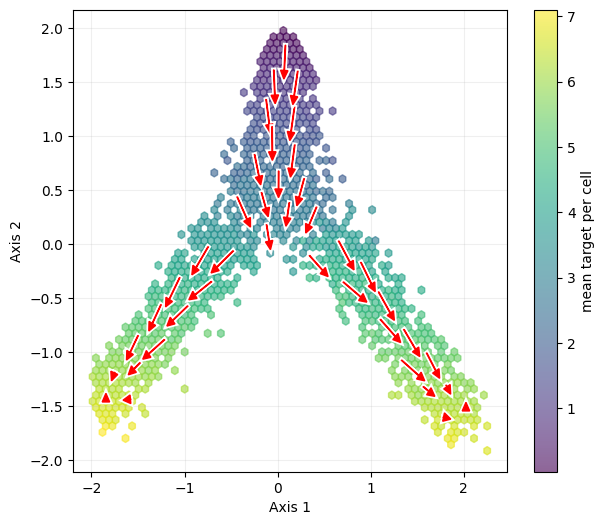

In [ ]:
# B) Learn φ to minimise OT objective only
# ----------------------------------------

from __future__ import annotations
from sklearn.cluster import KMeans

from gotflow import GOTFlow

# Example: use the same MLP phi you already use
phi = GOTFlow.make_mlp(d_in=X.shape[1], d_out=2, hidden=32, depth=3)
got = GOTFlow(blur=0.5, scaling=0.9, reach=0.01, phi=phi, debias=True)

got.fit(
    X,
    state_ids,
    edges=edges,          # <-- IMPORTANT: branching edges
    edge_weights=None,    # or dict {(1,2):1.0, ...}
    learn_phi=True,
    epochs=200,
    lr=1e-3,
    drift_mode="barycentric",
)


Z2 = got.zw_
V2 = got.Vw_

branch = np.where(state_ids==2, -1.0, np.where(state_ids==3, +1.0, 0.0))
t = X2[:, 1] + 0.4 * branch

#Z2, V2 = got.project_pls(n_components=2, standardize=True)
km = KMeans(n_clusters=40, n_init="auto", random_state=0)
cid = km.fit_predict(Z2)
P, U, counts, labs = GOTFlow.cluster_average(Z2, V2, cid, min_points=10)
got.plot_quiver(Z2, t, P, U, 
                figsize= (7, 6),
                gridsize= 60,
                head_width= 0.08,
                head_length= 0.08,
                width= 0.005,
                save=True)





<Figure size 700x600 with 0 Axes>

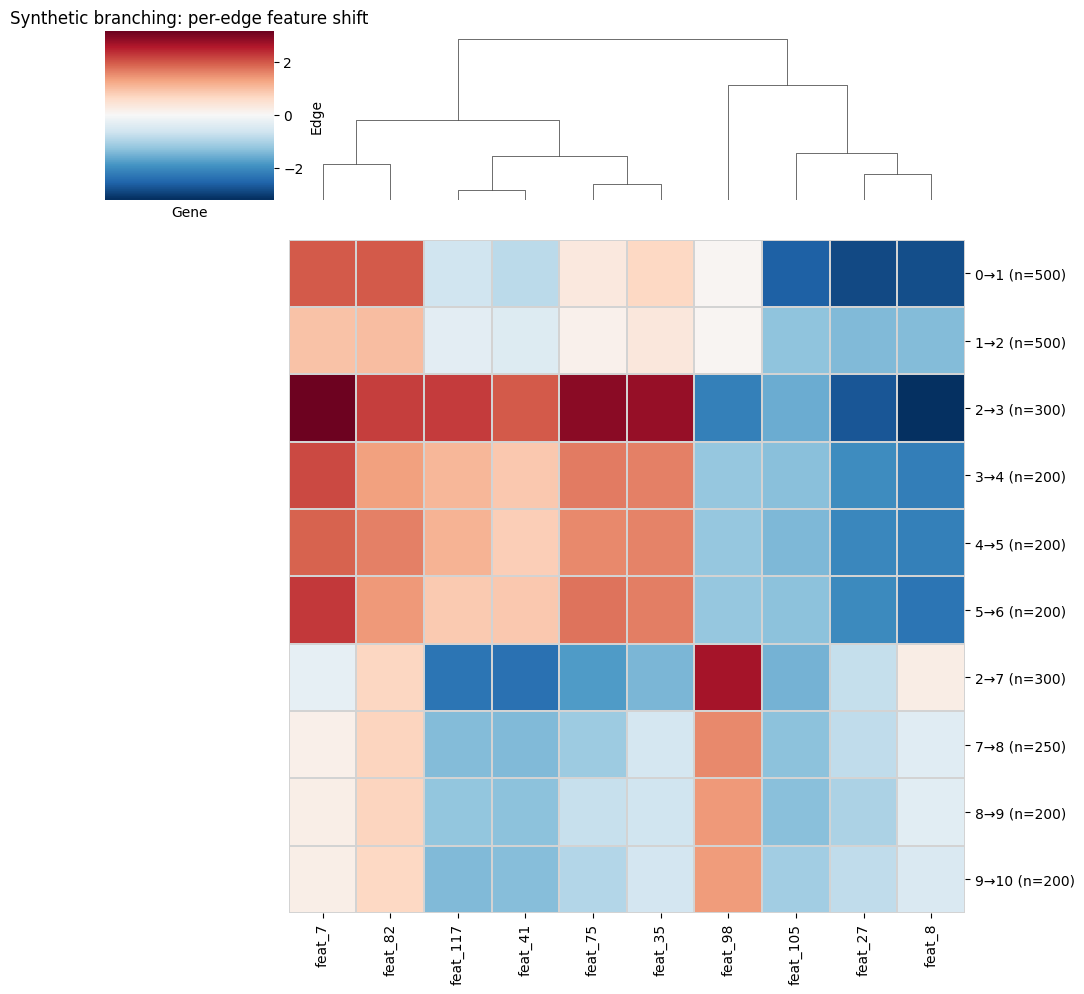

In [ ]:
# C) Edge Shift Analysis--------------
# ------------------------------------

import util_functions as util
top_n_genes = 10 # Number of genes to show in the heatmap (per edge)

heat, edge_df, top_list = util.edge_shift_heatmap_cached(
    got=got,
    X_gene=X,                 # your synthetic features
    gene_cols=[f"feat_{i}" for i in range(1, X.shape[1]+1)],
    edges_to_use=edges,       # <-- use the branching edge list you generated
    top_genes=10,
    signed=True,
    weight_by_mass=True,
    title="Synthetic branching: per-edge feature shift",
    figsize=(7, 6),
    save_path="Plots/edge_shift_heatmap.pdf",
)